# Titanic Dataset: EDA, Profiling, and Visual Analysis
### Zepto Capstone Project ? Module 2 (Part A)

In this notebook, I explore and clean the Titanic dataset. The goal is to profile the data, handle missing entries using percentage-based threshold rules, detect outliers, analyze correlations, and build a visual data story explaining survival patterns.

The raw dataset is loaded once via Seaborn and immediately saved as `titanic.csv` for offline fallback.

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset once and save offline fallback
df = sns.load_dataset('titanic')
df.to_csv('titanic.csv', index=False)
print(f"Dataset loaded and saved to titanic.csv. Shape: {df.shape}")

Dataset loaded and saved to titanic.csv. Shape: (891, 15)


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7 KB


In [3]:
df.describe()

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


## Missing Value Analysis & Threshold Strategy
Here I check missing counts and percentages across all columns. Based on the rule:
- **Under 5% missing**: drop the rows.
- **5% to 30% missing**: impute the column.
- **Over 30% missing**: drop column or encode as separate category.

In [4]:
nulls = df.isnull().sum()
missing = pd.DataFrame({'Missing Count': nulls, 'Percentage (%)': (nulls / len(df) * 100).round(2)})
print("Missing values per column:")
print(missing[missing['Missing Count'] > 0].sort_values(by='Percentage (%)', ascending=False))

Missing values per column:
             Missing Count  Percentage (%)
deck                   688           77.22
age                    177           19.87
embarked                 2            0.22
embark_town              2            0.22


### Decisions on Missing Values:
1. **`embarked` / `embark_town` (0.22%, 2 rows)**: Under 5%, so I simply drop these 2 rows. We lose almost no data.
2. **`age` (19.87%, 177 rows)**: Between 5% and 30%, so I impute with the median age (28.0 years), which avoids mean sensitivity to outliers.
3. **`deck` (77.22%, 688 rows)**: Way above 30%. Imputing more than 3/4 of a column would create mostly fabricated data, so I drop `deck` entirely.

In [5]:
df_clean = df.drop(columns=['deck']).copy()
df_clean = df_clean.dropna(subset=['embarked']).copy()
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
print(f"Cleaned dataset for EDA: {df_clean.shape}")

Cleaned dataset for EDA: (889, 14)


## Univariate Analysis & Outlier Detection (Age & Fare)
Using the IQR formula: $[Q1 - 1.5 \times IQR, Q3 + 1.5 \times IQR]$ to find outliers.

Age:
  Q1: 22.00, Q3: 35.00, IQR: 13.00
  Bounds: [2.50, 54.50]
  Outliers: 65 (7.31%)

Fare:
  Q1: 7.90, Q3: 31.00, IQR: 23.10
  Bounds: [-26.76, 65.66]
  Outliers: 114 (12.82%)

Fare Central Tendencies:
  Mean:   32.10
  Median: 14.45
  Mode:   8.05
Because Mean > Median > Mode, the fare distribution is clearly right-skewed with a long upper tail.


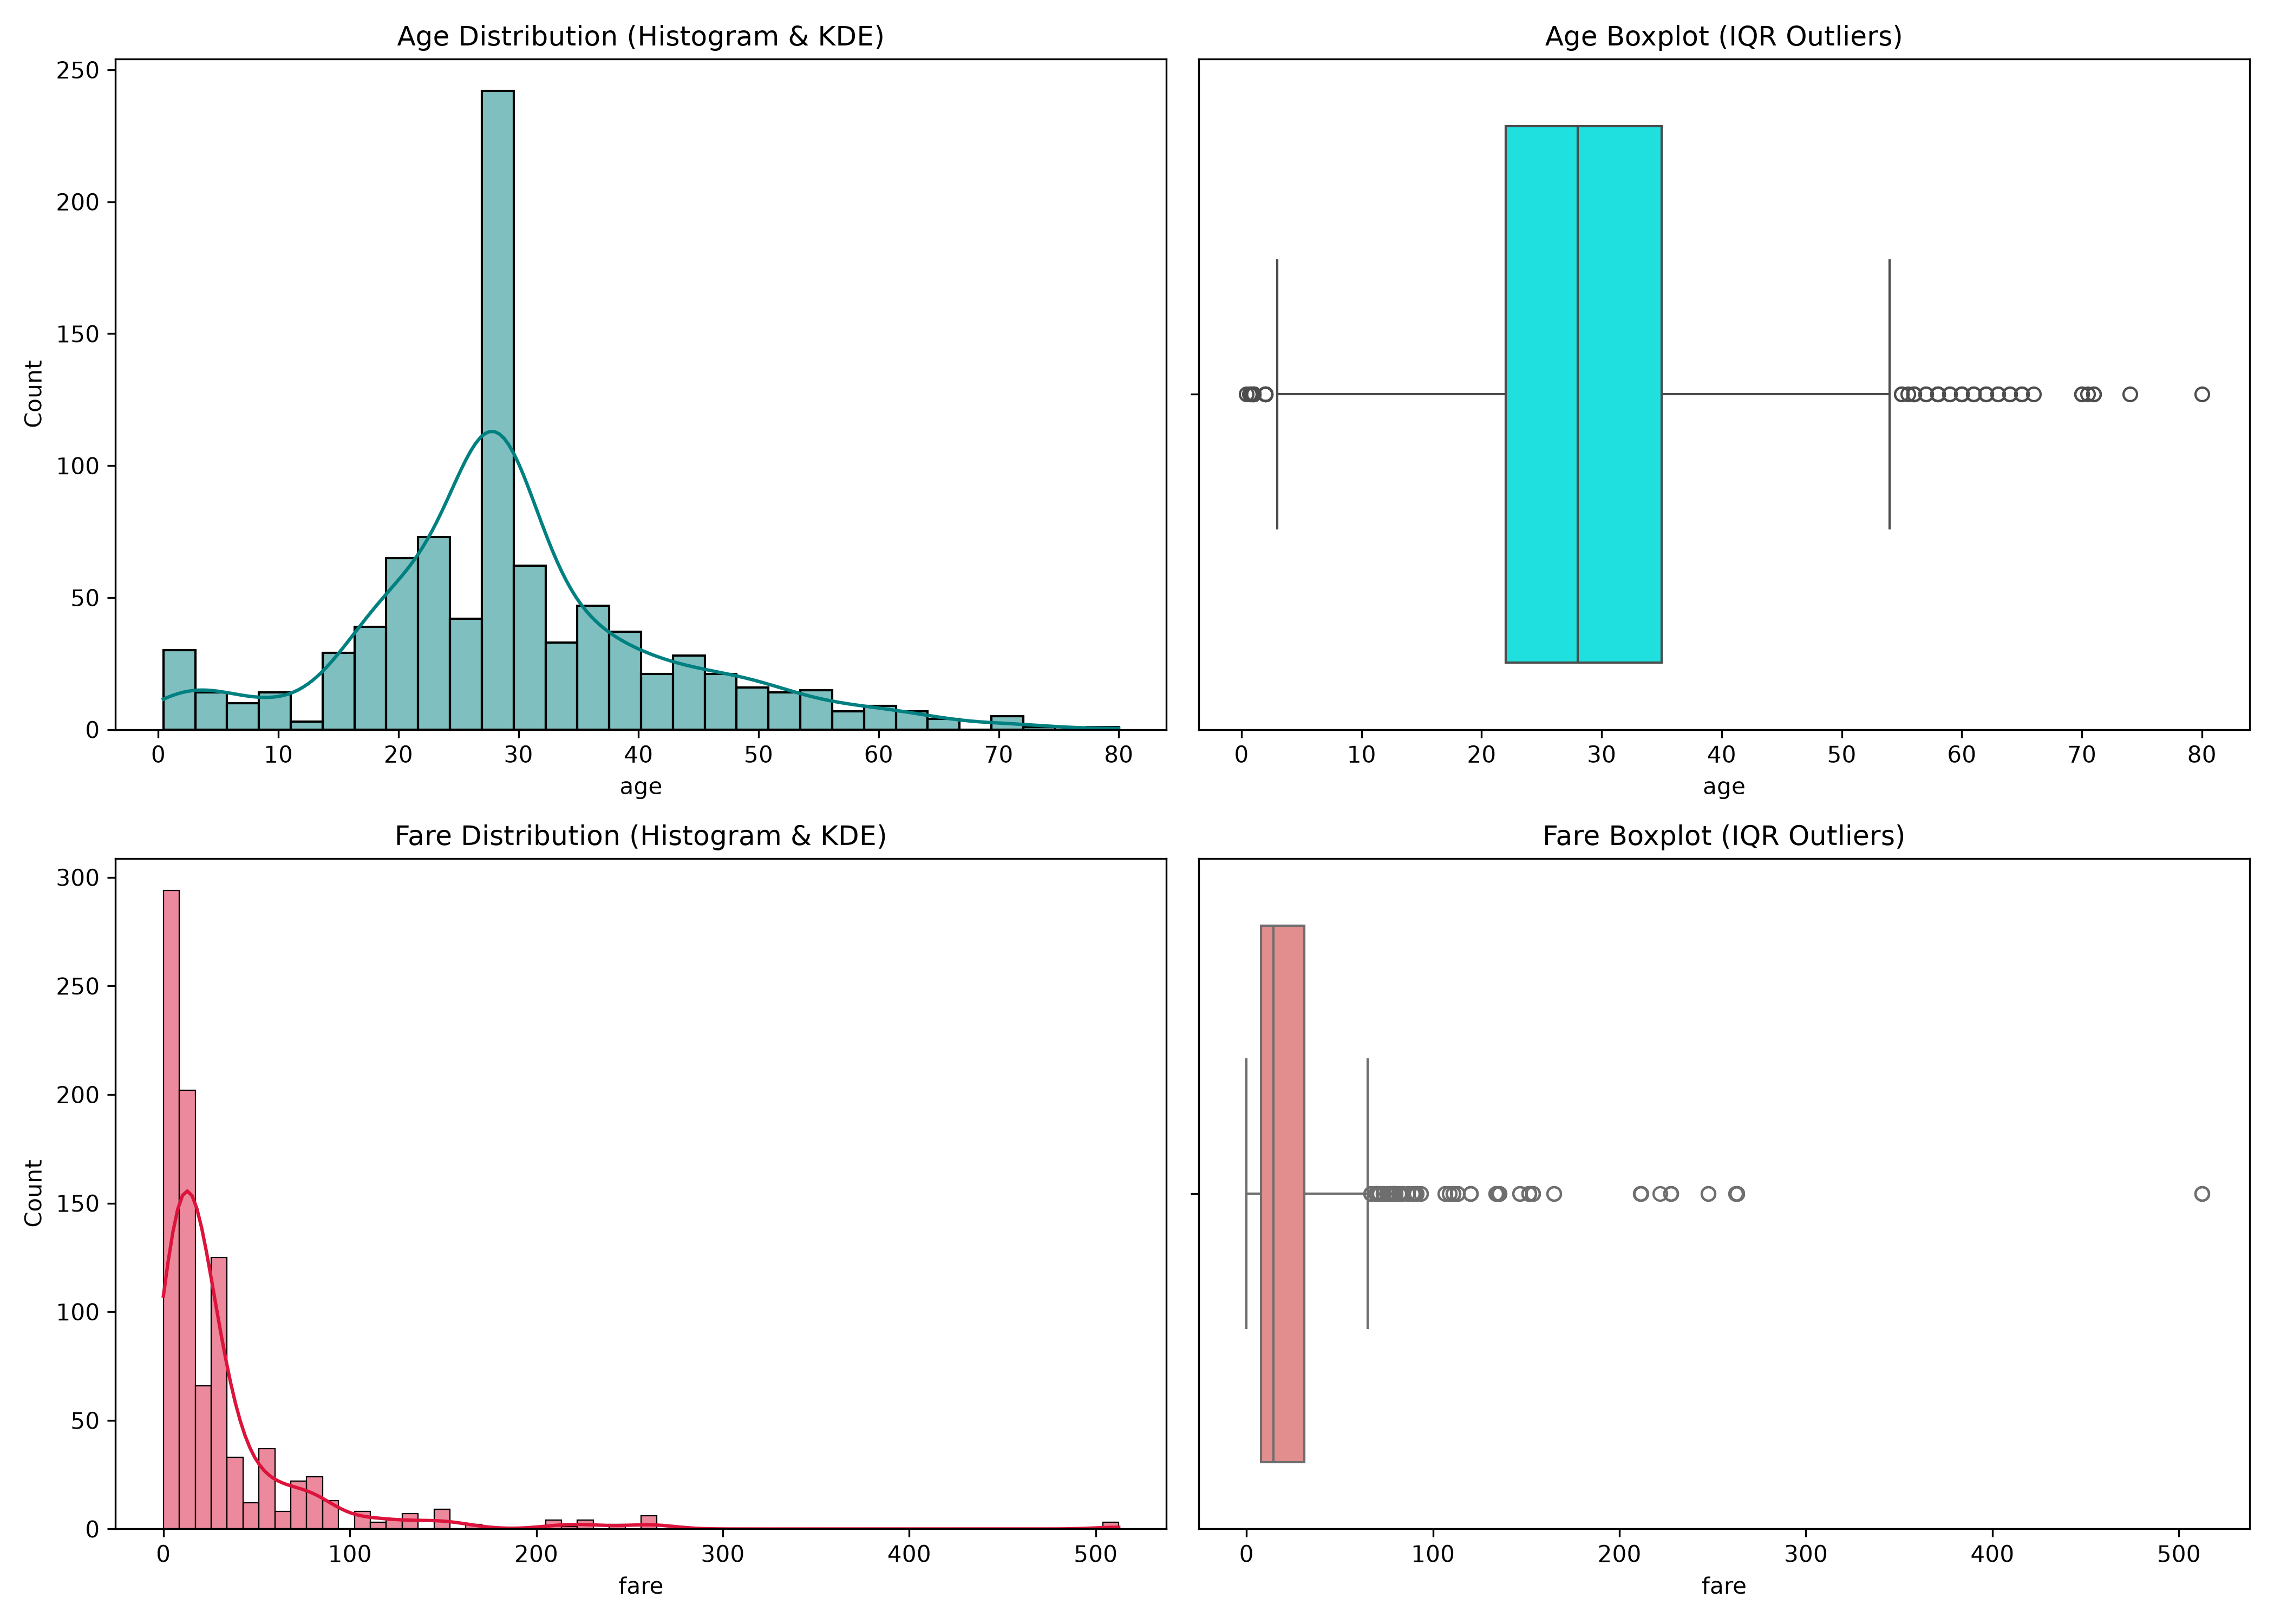

In [6]:
def check_iqr(col, label):
    q1, q3 = col.quantile(0.25), col.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = col[(col < low) | (col > high)]
    print(f"{label}:\n  Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}\n  Bounds: [{low:.2f}, {high:.2f}]\n  Outliers: {len(out)} ({len(out)/len(col)*100:.2f}%)\n")

check_iqr(df_clean['age'], "Age")
check_iqr(df_clean['fare'], "Fare")

f_mean, f_med, f_mode = df_clean['fare'].mean(), df_clean['fare'].median(), df_clean['fare'].mode()[0]
print(f"Fare Central Tendencies:\n  Mean:   {f_mean:.2f}\n  Median: {f_med:.2f}\n  Mode:   {f_mode:.2f}")
print("Because Mean > Median > Mode, the fare distribution is clearly right-skewed with a long upper tail.")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df_clean['age'], kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Age Distribution (Histogram & KDE)')
sns.boxplot(x=df_clean['age'], ax=axes[0, 1], color='cyan')
axes[0, 1].set_title('Age Boxplot (IQR Outliers)')
sns.histplot(df_clean['fare'], kde=True, ax=axes[1, 0], color='crimson')
axes[1, 0].set_title('Fare Distribution (Histogram & KDE)')
sns.boxplot(x=df_clean['fare'], ax=axes[1, 1], color='lightcoral')
axes[1, 1].set_title('Fare Boxplot (IQR Outliers)')
plt.tight_layout()
plt.show()

## Bivariate Analysis & 6x6 Correlation Matrix
Now let's compute survival rates using boolean masks and inspect the correlation matrix strictly restricted to the 6 numeric features (`survived`, `pclass`, `age`, `sibsp`, `parch`, `fare`). We exclude `adult_male` and `alone` as required.

Survival by Sex:
  Female: 74.04%
  Male:   18.89%

Survival by Pclass:
  Class 1: 62.62%
  Class 2: 47.28%
  Class 3: 24.24%

Survival by Sex + Pclass Interaction:
  Female, Class 1: 96.74%
  Female, Class 2: 92.11%
  Female, Class 3: 50.00%
  Male,   Class 1: 36.89%
  Male,   Class 2: 15.74%
  Male,   Class 3: 13.54%

6x6 Correlation Matrix:
          survived  pclass    age  sibsp  parch   fare
survived     1.000  -0.336 -0.070 -0.034  0.083  0.255
pclass      -0.336   1.000 -0.337  0.082  0.017 -0.548
age         -0.070  -0.337  1.000 -0.233 -0.171  0.094
sibsp       -0.034   0.082 -0.233  1.000  0.415  0.161
parch        0.083   0.017 -0.171  0.415  1.000  0.218
fare         0.255  -0.548  0.094  0.161  0.218  1.000


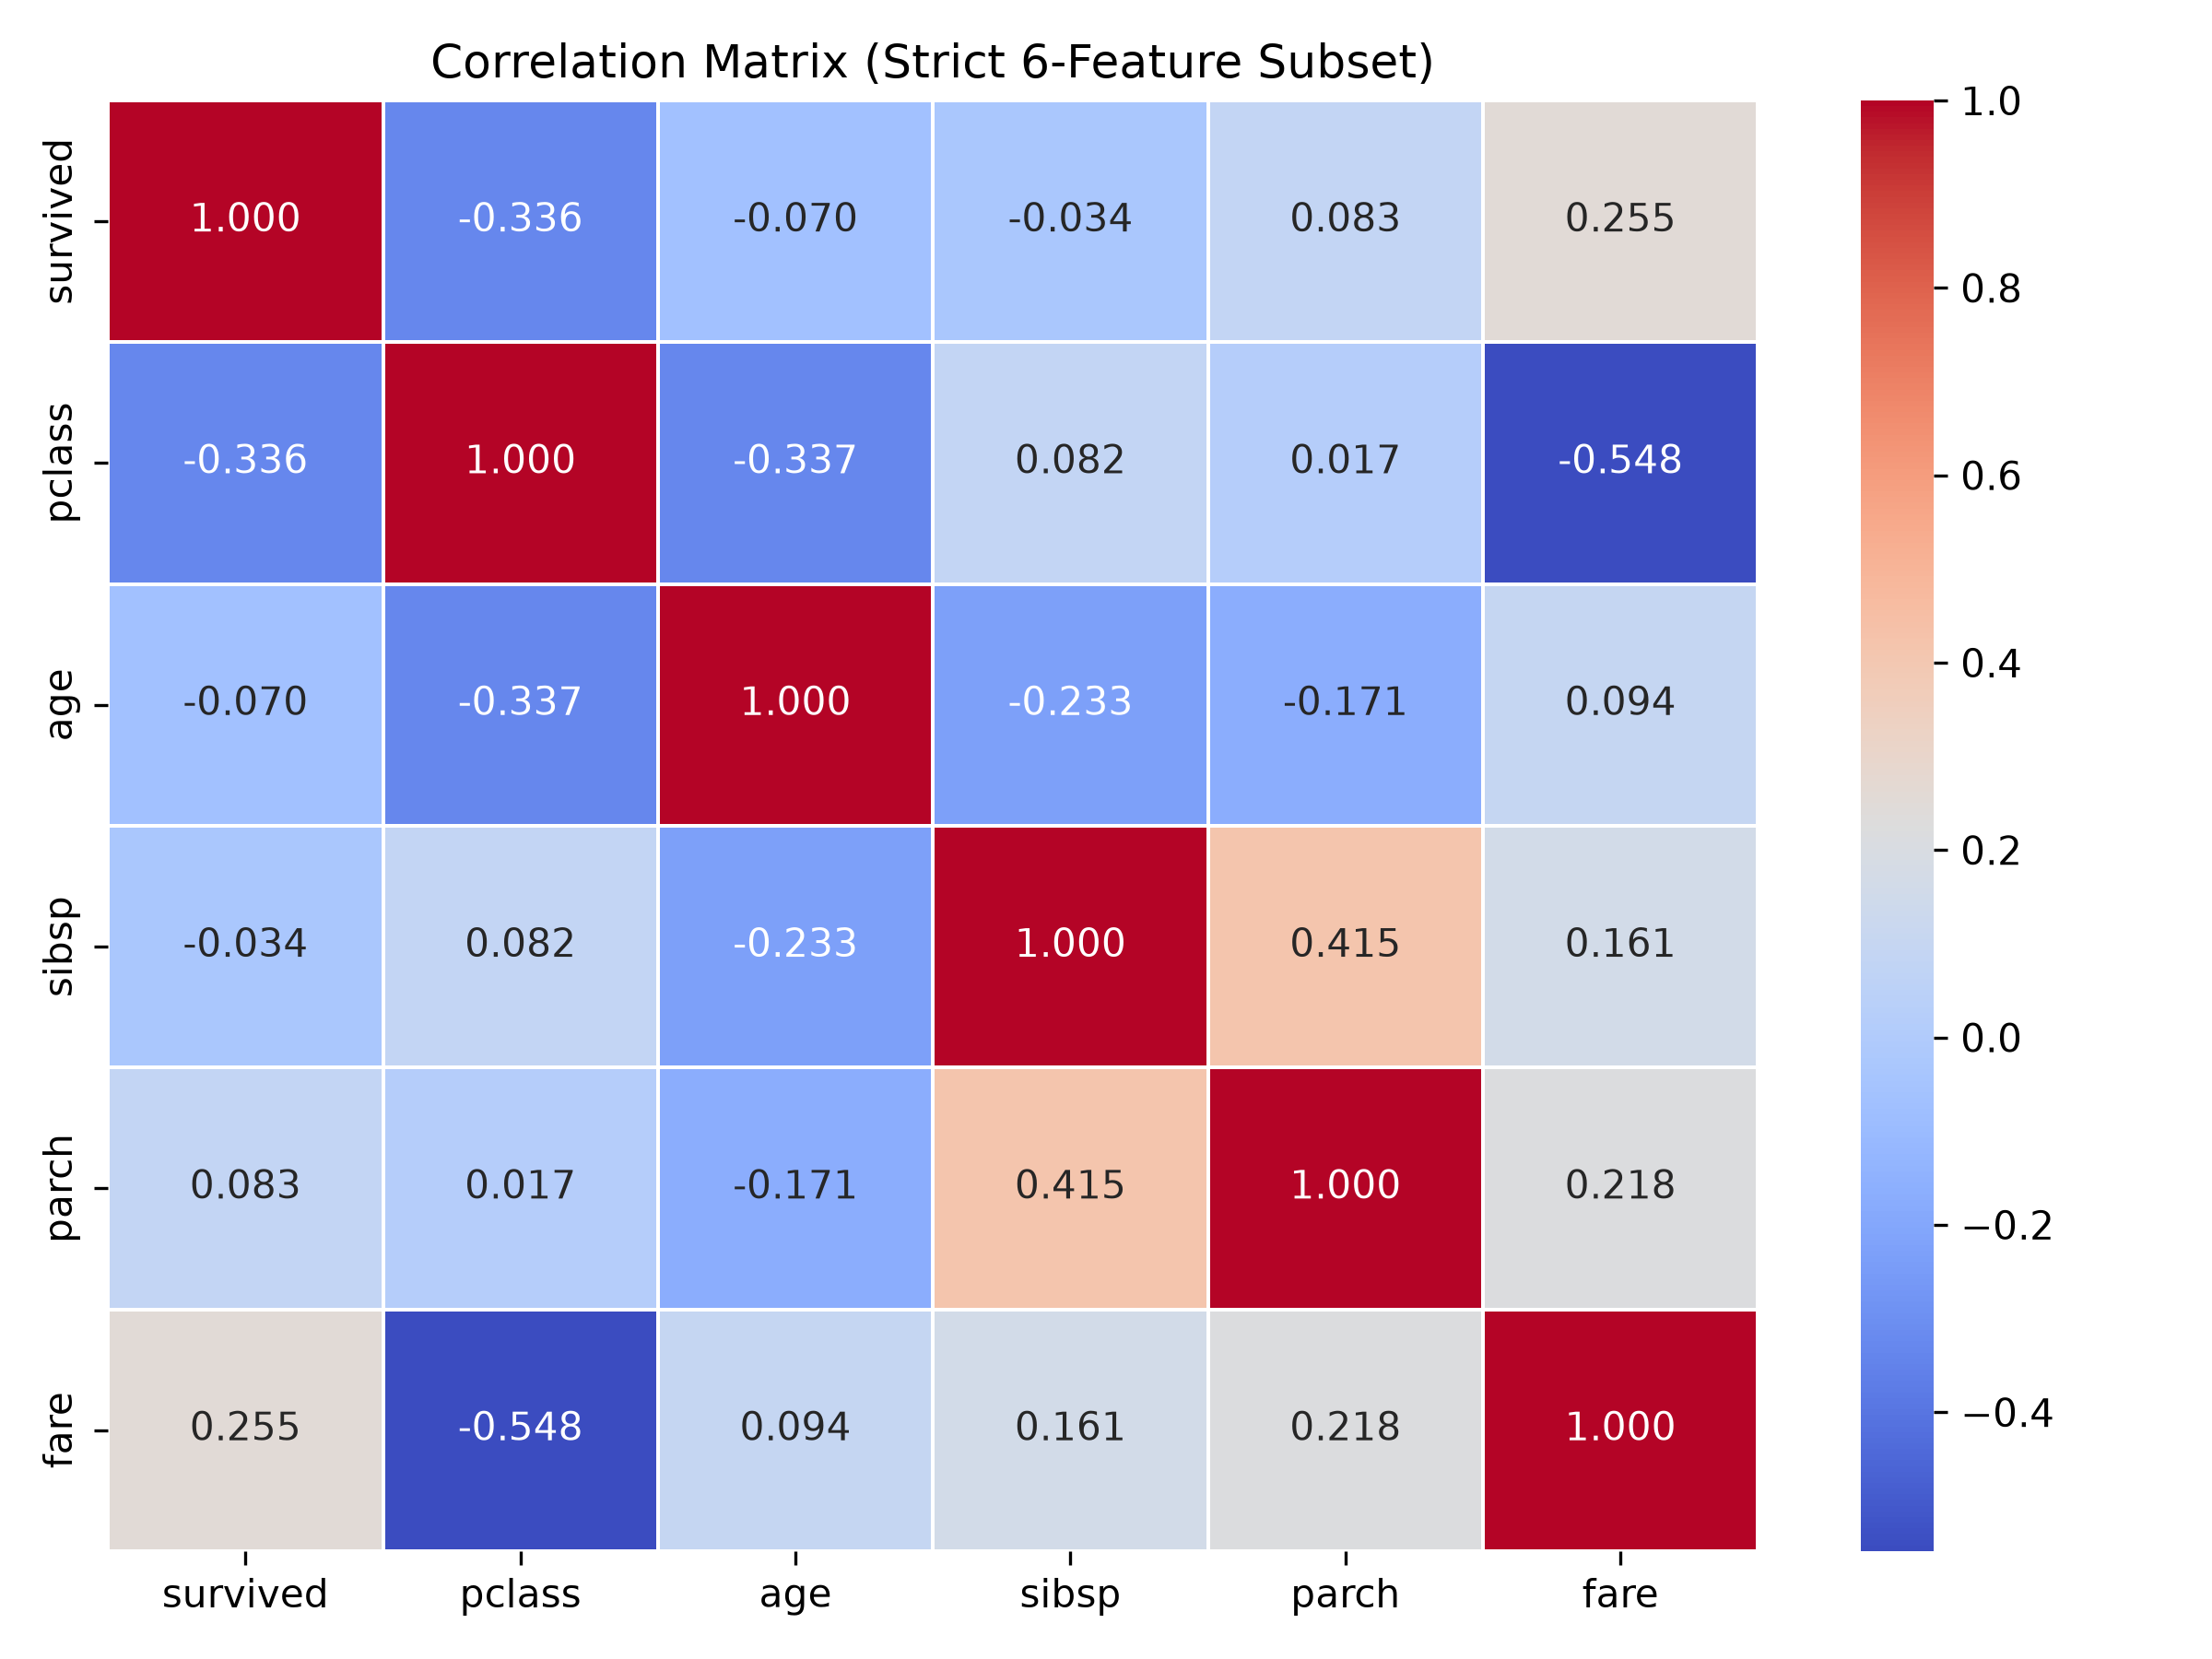

In [7]:
f_surv = df_clean[df_clean['sex'] == 'female']['survived'].mean()
m_surv = df_clean[df_clean['sex'] == 'male']['survived'].mean()
print(f"Survival by Sex:\n  Female: {f_surv*100:.2f}%\n  Male:   {m_surv*100:.2f}%\n")

print("Survival by Pclass:")
for p in [1, 2, 3]:
    p_surv = df_clean[df_clean['pclass'] == p]['survived'].mean()
    print(f"  Class {p}: {p_surv*100:.2f}%")

print("\nSurvival by Sex + Pclass Interaction:")
for s in ['female', 'male']:
    for p in [1, 2, 3]:
        sp_surv = df_clean[(df_clean['sex'] == s) & (df_clean['pclass'] == p)]['survived'].mean()
        print(f"  {s.capitalize():<6}, Class {p}: {sp_surv*100:.2f}%")

corr_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr = df_clean[corr_cols].corr()
print("\n6x6 Correlation Matrix:")
print(corr.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('Correlation Matrix (6 Numeric Features)')
plt.tight_layout()
plt.show()

### Top 2 Correlations Interpretation:
1. **`pclass` & `fare` ($r = -0.548$)**: Strongest off-diagonal correlation. Because 1st class is coded as 1 and 3rd class as 3, higher class numbers correspond to lower ticket prices.
2. **`sibsp` & `parch` ($r = 0.415$)**: Second strongest. People traveling with siblings/spouses were also very likely to travel with parents/children, representing cohesive family travel groups.

## Multivariate Visual Story (4 Charts)
These 4 charts tell the story of who survived and why:

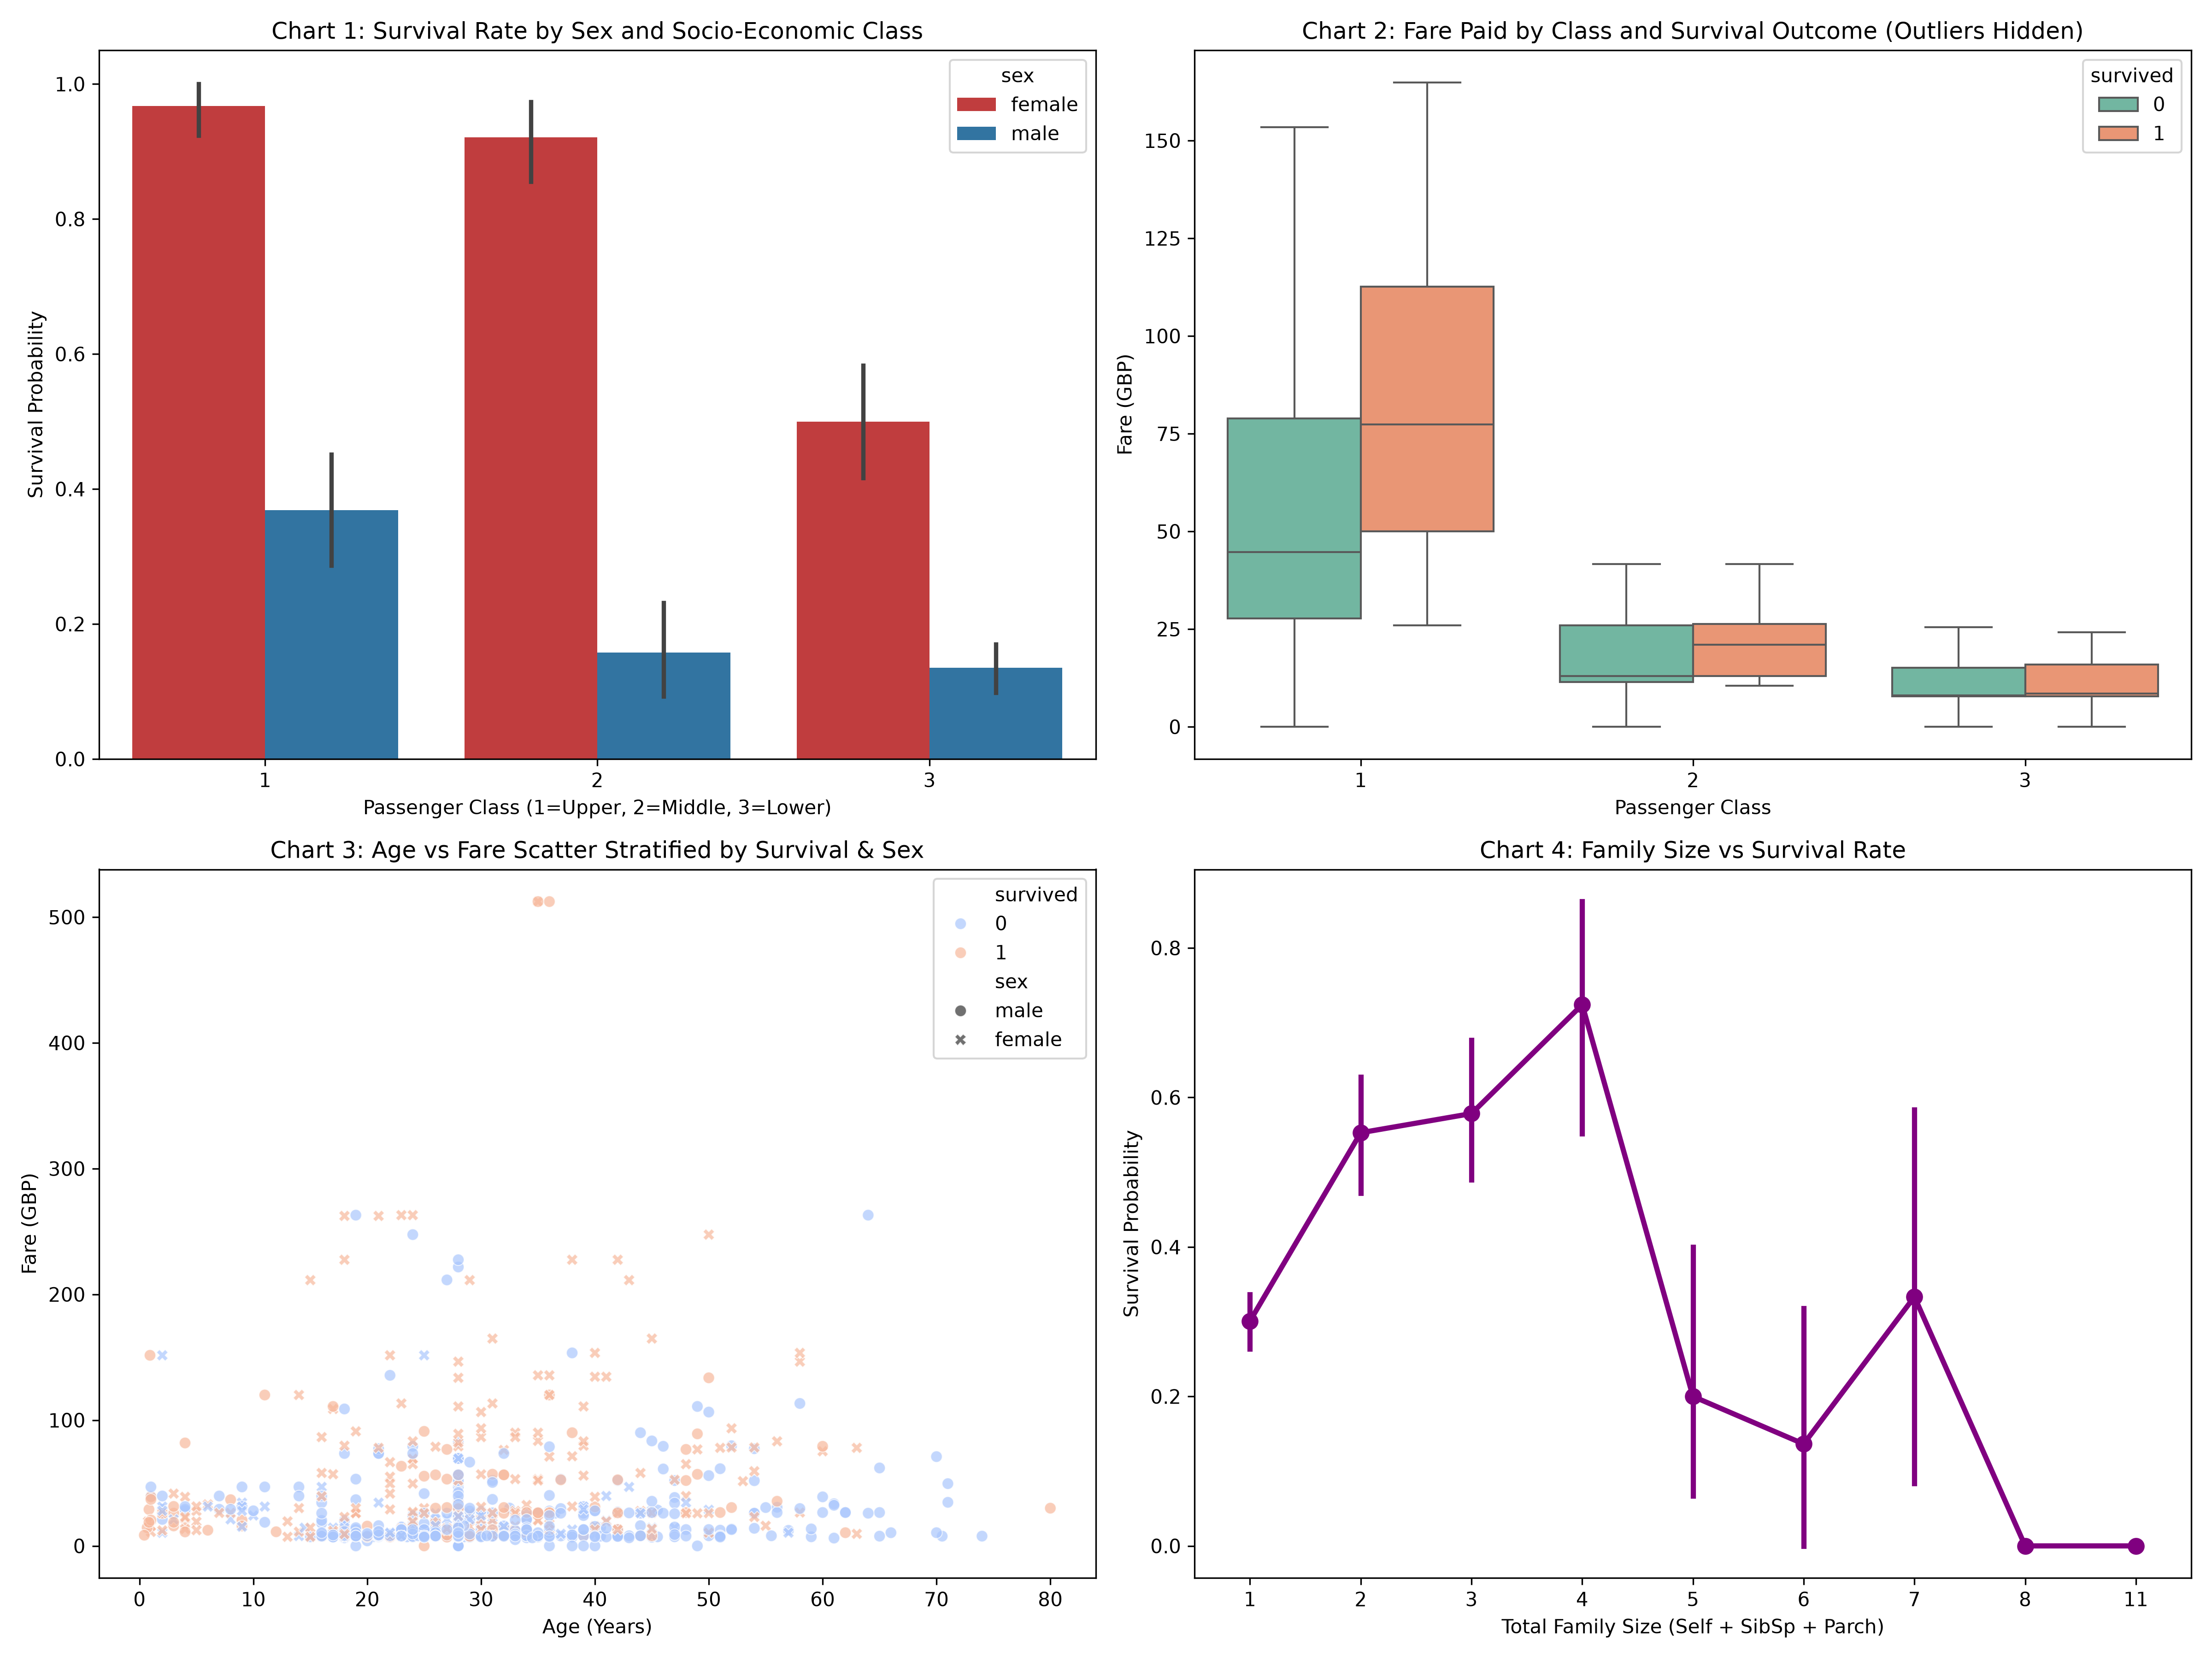

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Survival by Sex and Class
sns.barplot(x='pclass', y='survived', hue='sex', data=df_clean, palette={'female': '#d62728', 'male': '#1f77b4'}, ax=axes[0, 0])
axes[0, 0].set_title('Chart 1: Survival Rate by Sex and Passenger Class')
axes[0, 0].set_ylabel('Survival Rate')

# Chart 2: Fare by Class and Survival
sns.boxplot(x='pclass', y='fare', hue='survived', data=df_clean, palette='Set2', showfliers=False, ax=axes[0, 1])
axes[0, 1].set_title('Chart 2: Fare Distribution by Class and Survival')
axes[0, 1].set_ylabel('Fare (GBP)')

# Chart 3: Age vs Fare
sns.scatterplot(x='age', y='fare', hue='survived', style='sex', data=df_clean, alpha=0.7, palette='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title('Chart 3: Age vs Fare Scatter Stratified by Survival & Sex')
axes[1, 0].set_ylabel('Fare (GBP)')

# Chart 4: Family size
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1
sns.pointplot(x='family_size', y='survived', data=df_clean, color='purple', ax=axes[1, 1])
axes[1, 1].set_title('Chart 4: Family Size vs Survival Rate')
axes[1, 1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

### Interpretation of Multivariate Charts:
- **Chart 1**: Females had vastly higher survival rates across every class (over 90% in 1st/2nd class). Class privilege also played a major role: 1st class women had nearly 97% survival compared to 50% for 3rd class women.
- **Chart 2**: Within each class, survivors paid noticeably higher fares on average than victims. Premium cabin locations likely gave faster physical access to upper boat decks.
- **Chart 3**: Almost all passengers who paid over 100 GBP survived, while non-surviving males were heavily clustered in the bottom-left corner (cheap fares, low-to-mid ages).
- **Chart 4**: Solo travelers had low survival (~30%). Small families (2 to 4 members) had the best survival rates (55%?70%). Very large families (5+) experienced sharply lower survival, likely due to difficulties keeping families together during evacuation.

## Exploratory Standardization Check
Here I test applying standard scaling $z = (x - \mu) / \sigma$ on `age` and `fare` across the dataset to confirm the transformed features have mean $\approx 0$ and standard deviation $\approx 1$. (Note: in the actual modeling stage, scaling is fit only on the train split).

Age  Before: Mean = 29.3152, Std = 12.9849
Age  After:  Mean = 2.7974e-16, Std = 1.0000
Fare Before: Mean = 32.0967, Std = 49.6975
Fare After:  Mean = 1.3587e-16, Std = 1.0000


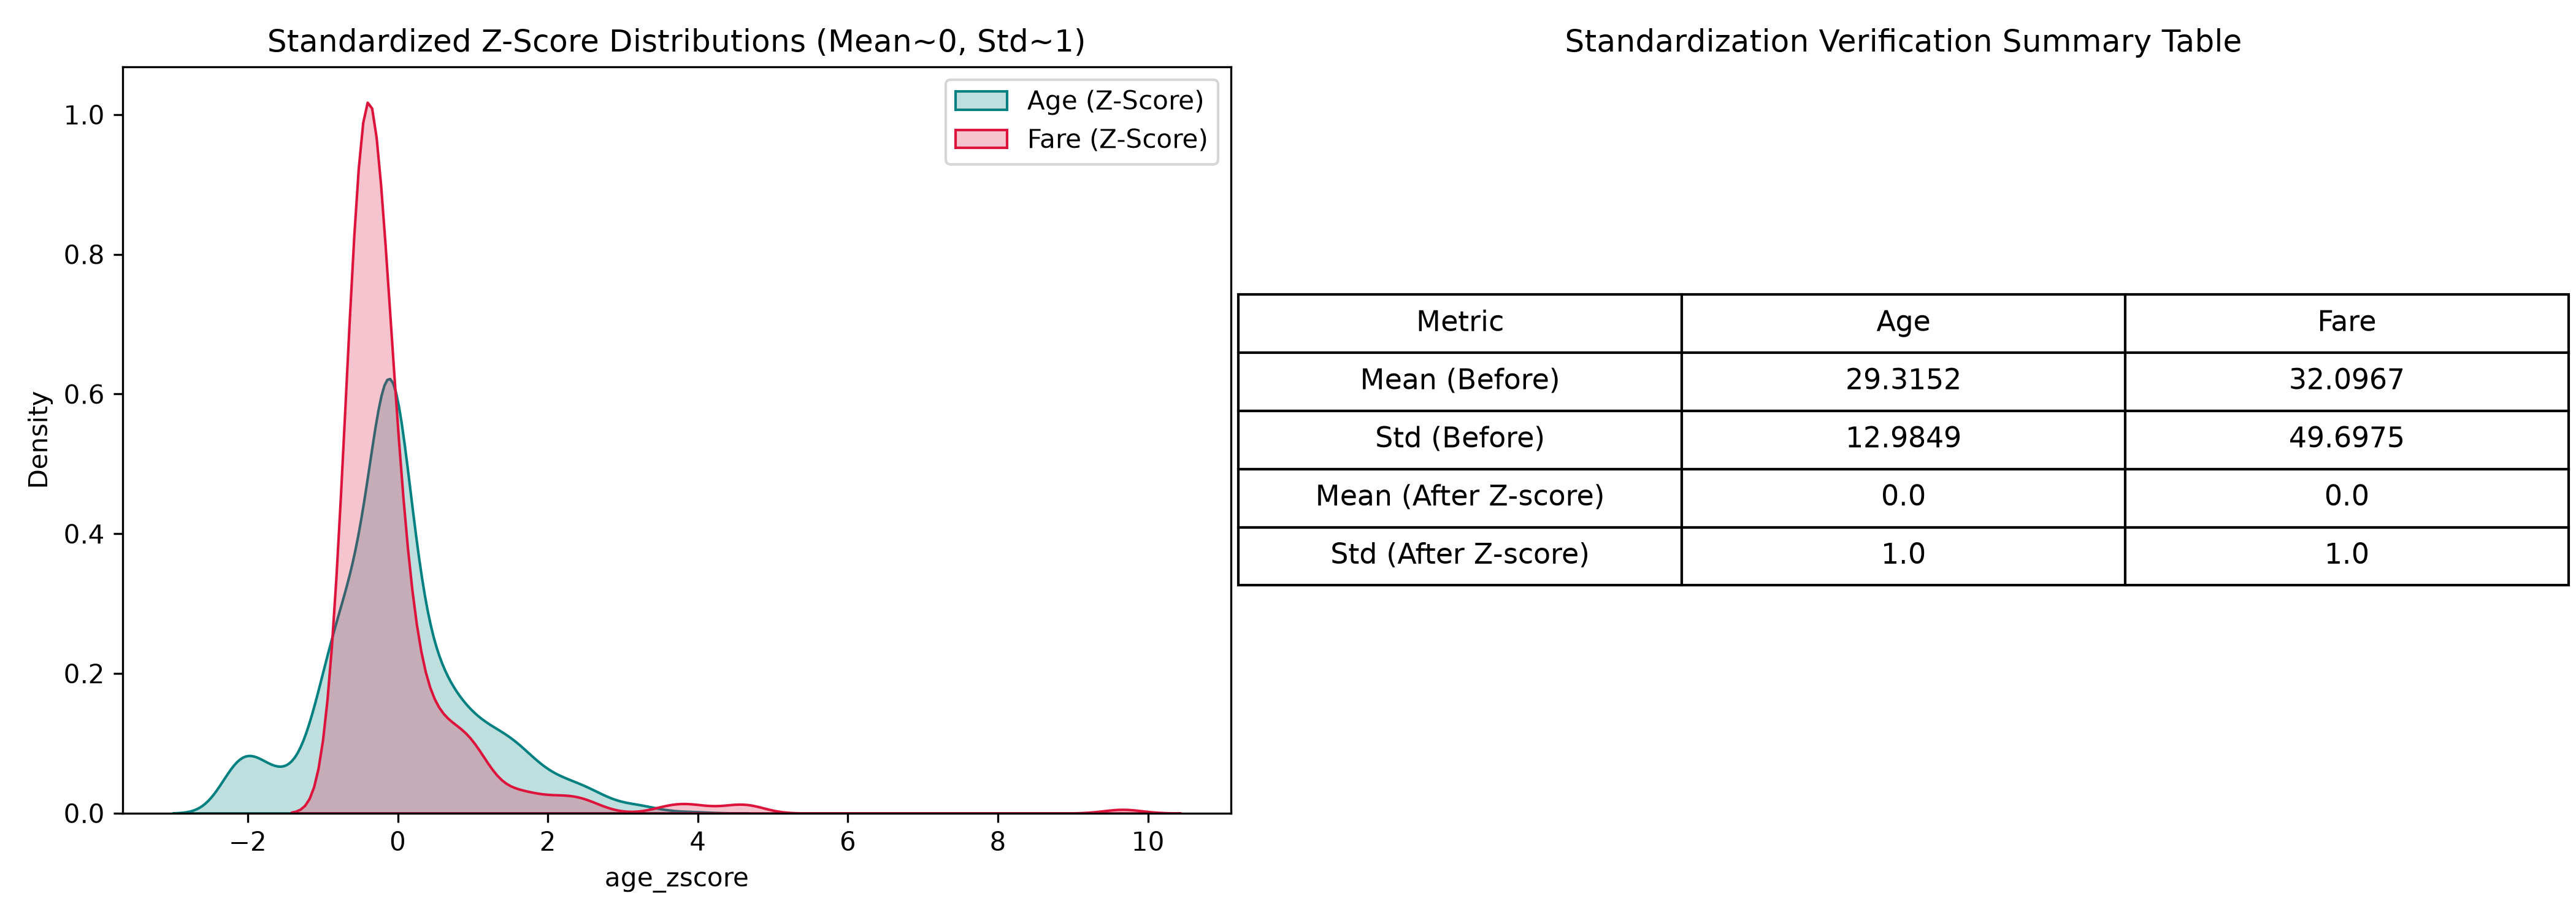

In [9]:
age_orig_mean, age_orig_std = df_clean['age'].mean(), df_clean['age'].std()
fare_orig_mean, fare_orig_std = df_clean['fare'].mean(), df_clean['fare'].std()

df_clean['age_zscore'] = (df_clean['age'] - age_orig_mean) / age_orig_std
df_clean['fare_zscore'] = (df_clean['fare'] - fare_orig_mean) / fare_orig_std

print(f"Age  Before: Mean = {age_orig_mean:.4f}, Std = {age_orig_std:.4f}")
print(f"Age  After:  Mean = {df_clean['age_zscore'].mean():.4e}, Std = {df_clean['age_zscore'].std():.4f}")
print(f"Fare Before: Mean = {fare_orig_mean:.4f}, Std = {fare_orig_std:.4f}")
print(f"Fare After:  Mean = {df_clean['fare_zscore'].mean():.4e}, Std = {df_clean['fare_zscore'].std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(df_clean['age_zscore'], label='Age (Z-Score)', ax=axes[0], color='teal', fill=True)
sns.kdeplot(df_clean['fare_zscore'], label='Fare (Z-Score)', ax=axes[0], color='crimson', fill=True)
axes[0].set_title('Standardized Z-Score Distributions (Mean~0, Std~1)')
axes[0].legend()

stats_df = pd.DataFrame({
    'Metric': ['Mean (Before)', 'Std (Before)', 'Mean (After)', 'Std (After)'],
    'Age': [round(age_orig_mean, 2), round(age_orig_std, 2), round(df_clean['age_zscore'].mean(), 4), round(df_clean['age_zscore'].std(), 2)],
    'Fare': [round(fare_orig_mean, 2), round(fare_orig_std, 2), round(df_clean['fare_zscore'].mean(), 4), round(df_clean['fare_zscore'].std(), 2)]
})
axes[1].axis('off')
t = axes[1].table(cellText=stats_df.values, colLabels=stats_df.columns, loc='center', cellLoc='center')
t.scale(1.2, 1.8)
axes[1].set_title('Standardization Verification Table')
plt.tight_layout()
plt.show()